In [1]:
import os
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../../data/dataset_selection_sans_leger.csv"
df = pd.read_csv(csv_path)

assert "path" in df.columns and "label" in df.columns, "Le CSV doit contenir 'path' et 'label'"
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants dans le CSV. Je les enlève.")
    df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)
else:
    df = df.drop(columns=["exists"])

In [2]:
import numpy as np

def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    gray = arr.mean(axis=2)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [3]:
# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val/test (80/10/10)
# -------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)
test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 4) Dataset + Transforms
# DenseNet-201 : résolution 224x224 (standard ImageNet)
# -------------------------
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        y = int(row["y"])
        img = Image.open(path).convert("RGB")
        if self.do_crop:
            img = crop_black_border_pil(img, thr=10, pad=10)
        if self.transform:
            img = self.transform(img)
        return img, y

train_ds = FundusDataset(train_df, transform=train_tfms)
val_ds   = FundusDataset(val_df,   transform=val_tfms)
test_ds  = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 5058 | Val : 633 | Test : 632


In [4]:
# -------------------------
# 5) Modèle DenseNet-201 (Transfer Learning)
# Le classifier est model.classifier (Linear directe, pas de liste)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)

Device: cuda


In [5]:
# -------------------------
# 6) Fonctions train / eval
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

In [6]:
# -------------------------
# 7) Entraînement avec early stopping + sauvegarde du meilleur modèle
# -------------------------
best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200
best_model_path = "densenet201_best.pth"

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
          f"lr {current_lr:.2e}")

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping à l'epoch {epoch}")
        break

print(f"\nMeilleure val acc : {best_val_acc:.4f}")

Epoch 01 | train loss 0.4585 acc 0.8221 | val loss 0.2595 acc 0.9021 | lr 1.00e-04
Epoch 02 | train loss 0.2765 acc 0.8970 | val loss 0.2884 acc 0.9052 | lr 1.00e-04
Epoch 03 | train loss 0.2175 acc 0.9162 | val loss 0.2516 acc 0.9163 | lr 1.00e-04
Epoch 04 | train loss 0.1714 acc 0.9353 | val loss 0.2782 acc 0.8957 | lr 1.00e-04
Epoch 05 | train loss 0.1539 acc 0.9405 | val loss 0.2474 acc 0.9052 | lr 1.00e-04
Epoch 06 | train loss 0.1301 acc 0.9526 | val loss 0.2656 acc 0.9052 | lr 1.00e-04
Epoch 07 | train loss 0.1080 acc 0.9595 | val loss 0.1937 acc 0.9447 | lr 1.00e-04
Epoch 08 | train loss 0.0952 acc 0.9668 | val loss 0.2597 acc 0.9273 | lr 1.00e-04
Epoch 09 | train loss 0.1394 acc 0.9494 | val loss 0.2392 acc 0.9226 | lr 1.00e-04
Epoch 10 | train loss 0.1192 acc 0.9579 | val loss 0.2224 acc 0.9179 | lr 1.00e-04
Epoch 11 | train loss 0.0741 acc 0.9747 | val loss 0.2084 acc 0.9352 | lr 5.00e-05
Epoch 12 | train loss 0.0502 acc 0.9846 | val loss 0.2004 acc 0.9352 | lr 5.00e-05
Epoc

In [ ]:
# Recharger le meilleur modèle avant évaluation
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()
print(f"Best model rechargé depuis best_model_path")

/tmp/ipykernel_239431/380761643.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=device))


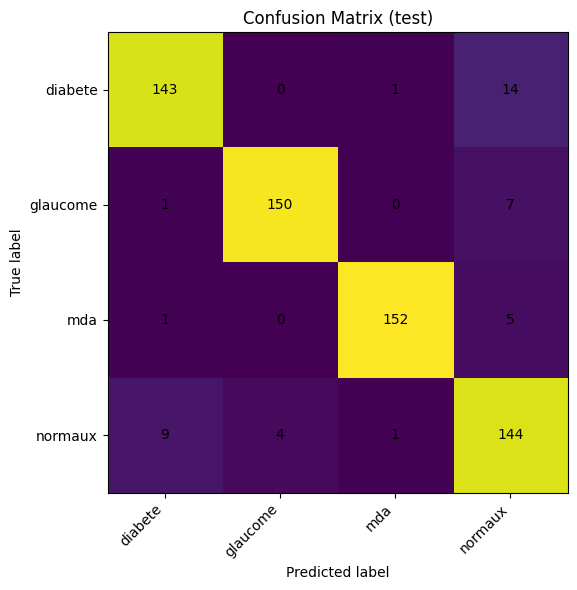

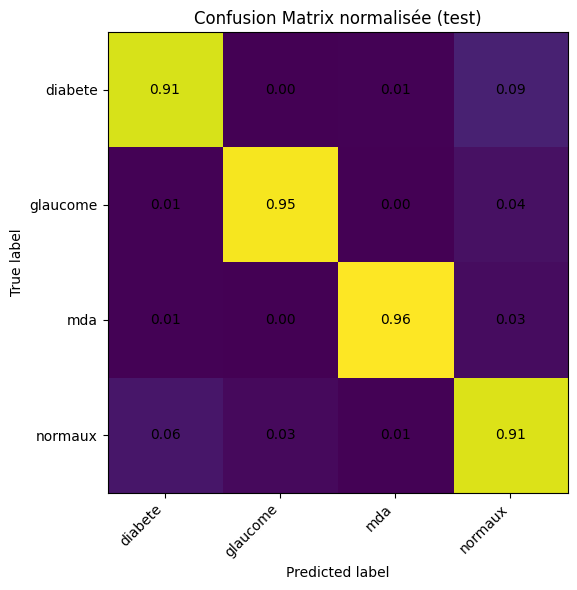


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.9286    0.9051    0.9167       158
    glaucome     0.9740    0.9494    0.9615       158
         mda     0.9870    0.9620    0.9744       158
     normaux     0.8471    0.9114    0.8780       158

    accuracy                         0.9320       632
   macro avg     0.9342    0.9320    0.9327       632
weighted avg     0.9342    0.9320    0.9327       632

AUC-ROC macro (OvR) : 0.9902


In [7]:
# -------------------------
# 8) Évaluation sur le test set (meilleur modèle)
# -------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

model.load_state_dict(torch.load(best_model_path, map_location=device))

def predict_on_loader(model, loader, device):
    model.eval()
    y_true, y_pred, y_proba = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1).cpu().numpy()
            y_pred.append(preds)
            y_true.append(y.cpu().numpy())
            y_proba.append(probs.cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_proba)

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm[i, j]:.2f}" if normalize else str(cm[i, j]),
                    ha="center", va="center")
    plt.tight_layout()
    plt.show()

y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)
cm = confusion_matrix(y_true, y_pred)

plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix normalisée (test)", normalize=True)

print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))

# AUC-ROC multiclasse (one-vs-rest)
try:
    auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    print(f"AUC-ROC macro (OvR) : {auc:.4f}")
except Exception as e:
    print(f"AUC-ROC non calculable : {e}")

Nombre d'images mal classées : 43


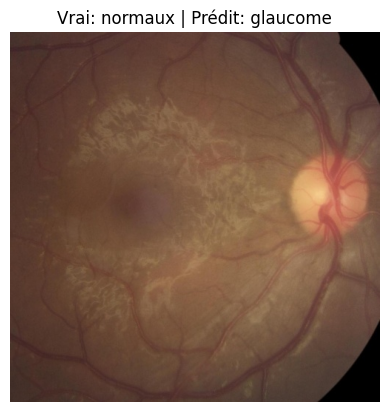

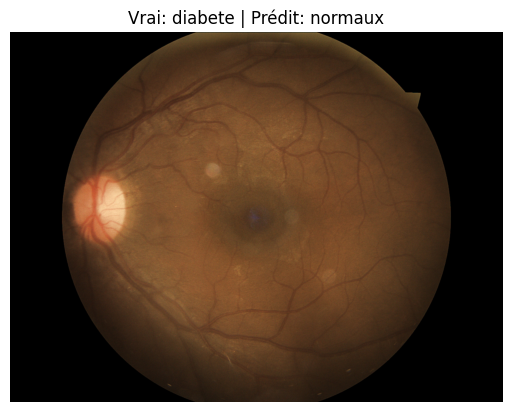

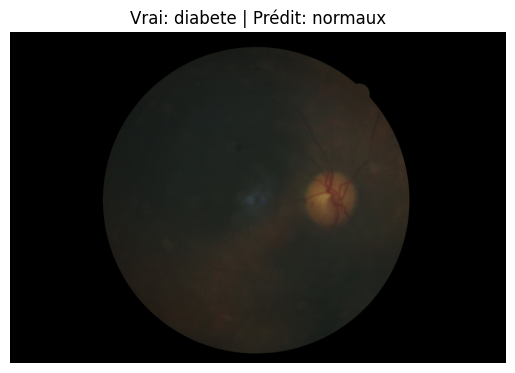

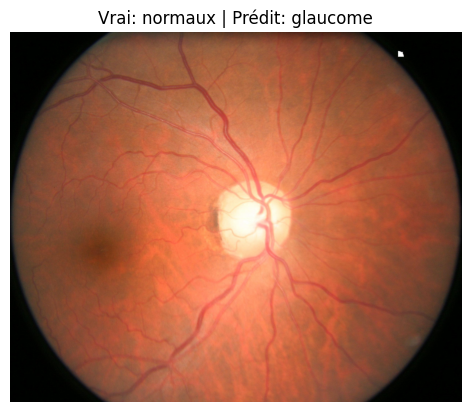

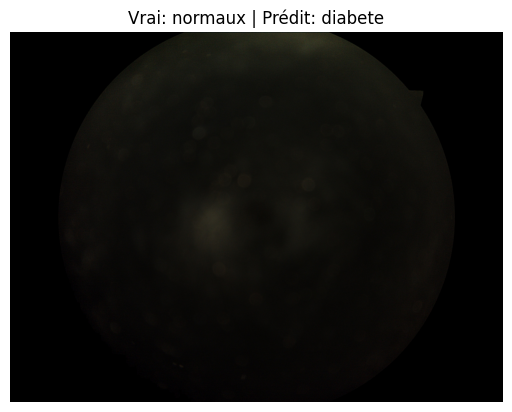

In [8]:
# -------------------------
# 9) Exemples d'images mal classées
# -------------------------
import matplotlib.pyplot as plt
df_test = test_df.reset_index(drop=True)
classes = le.classes_
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    img_path = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label}")
    plt.axis("off")
    plt.show()